In [1]:
library(tidyverse)
library(janitor)
library(omicsTools)
library(PubChemR)
library(classyfireR)
library(VennDiagram)
library(grid)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



This is omicsTools version 1.1.7.
omicsTools is free software and comes with ABSOLUTELY NO WARRANTY.
Please use at your own risk.

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract


Loading required pa

In [2]:
theme_function = function(){
 theme_classic() +
            theme(
                panel.grid.major.x = element_line(color = "gray80", linetype = "dashed"),
                panel.grid.major.y = element_line(color = "gray80", linetype = "dashed"),
                strip.text.y = element_text(angle = 0, size = 12),
                strip.text.x = element_text(angle = 0, size = 12),
                text = element_text(size = 12),
                axis.title.x = element_text(size = 12), 
                axis.title.y = element_text(size = 12),
                axis.text.x = element_text(size = 12), 
                axis.text.y = element_text(size = 12))
    }

In [3]:
# QC control, remove impossible compounds
# siloxane and trimethylsilylated peaks

In [4]:
removed = readxl::read_excel('./data/pdms_data/STable1_JMD Edits.xlsx', sheet = "Removed") %>% pull(Name) %>% unique()
length(removed)

[1] 31

In [5]:
# Direct skin PDMS (not controls)
sample_id = as.character(c(1:4))
location_id = c("A", "B",'C', "D")
patterns = expand.grid(sample_id, location_id) %>% 
    mutate(pattern = paste0(Var1, Var2))
pattern_id = patterns$pattern

In [6]:
datas= list()
for (i in pattern_id){
    out = tryCatch(
        expr = {
            readxl::read_excel('./data/pdms_data/Emory Skin Sample Data.xlsx', sheet = i) %>% 
                group_by(CAS) %>% 
                mutate(Area_sum = sum(Area)) %>%
                filter(!duplicated(CAS)) %>% 
                select(Name, CAS, !!i := Area_sum) %>% 
                # remove siloxane and trimethylsilylated peaks 
                filter(!Name %in% removed)
        }, error = function(e){
            NULL
        }
        )
    datas[[i]] = out    
}

In [7]:
# combine
data = reduce(datas, full_join, by = c("Name", "CAS")) 

In [8]:
feature_ = data[, c(1,2)]
X = data[, c(-1, -2)]
dim(X)

[1] 1069   14

In [9]:
# remove call rate for features
n_samples = ncol(X)
prop_non_na = apply(!is.na(X), 1, sum)/n_samples

# keep at least m samples
m = 3
keep = prop_non_na > m/n_samples
sum(keep)

[1] 160

In [10]:
X = X[keep, ]
feature_ = feature_[keep, ]
dim(X)

[1] 160  14

In [11]:
data_ = bind_cols(feature_, log1p(X))
data_ %>% write_csv("./results/pdms_feature_filtered_normalized.csv")

In [12]:
# remove call rate for samples
n_samples = ncol(X)
prop_non_na = apply(!is.na(X), 2, sum)/nrow(X)

# keep at least m features
m = 17.4
keep = prop_non_na > m/nrow(X)
print(m/nrow(X))
sum(keep)

[1] 0.10875


[1] 13

In [13]:
X = X[, keep]
dim(X)

[1] 160  13

In [14]:
# total ion current (TIC) normalization is valid? 
# if many features, untargeted measurement, TIC can normalize technical sample variation.
# here, we have targeted GC-MS, and we expect some skin locations may have better/worse compound catchment, with sample variability (large).
# in this case, TIC may distort the signal.

# TIC
# X_rel = sweep(X, 2, colSums(X, na.rm = TRUE), FUN = "/")

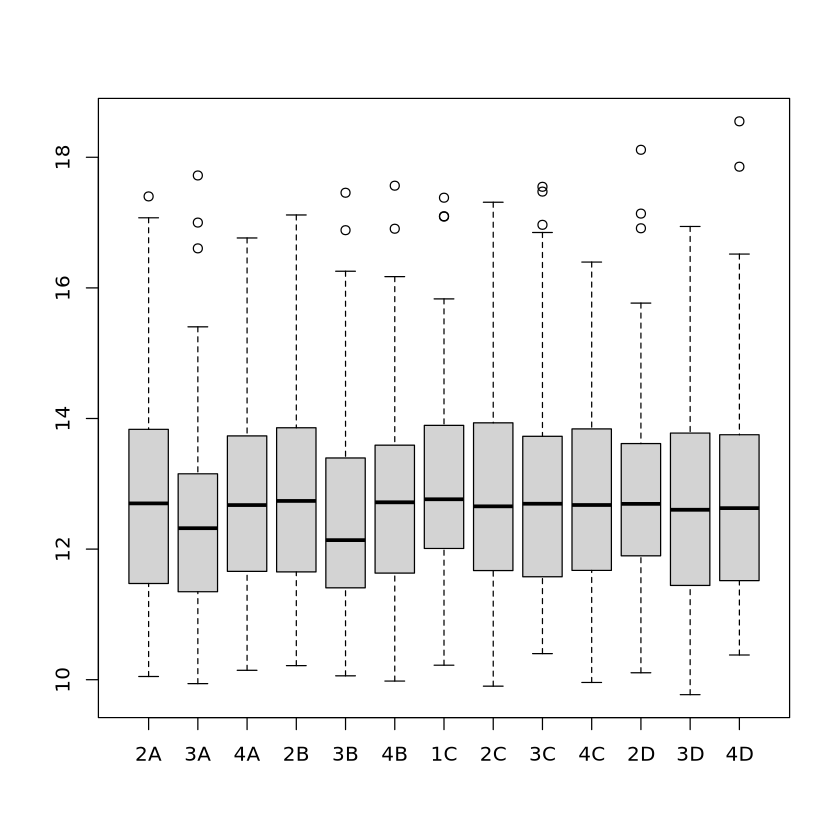

In [15]:
# simply log normalization
boxplot(log1p(X))

In [16]:
data_selected = bind_cols(feature_, log1p(X))

In [17]:
data_selected %>% write_csv("./results/pdms_filtered_normalized.csv")

In [18]:
data = read_csv("./results/pdms_filtered_normalized.csv")

Rows: 160 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Name, CAS
dbl (13): 2A, 3A, 4A, 2B, 3B, 4B, 1C, 2C, 3C, 4C, 2D, 3D, 4D

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [19]:
print(dim(data))
data %>% pull(Name)

[1] 160  15


[1] "Cyacetacide"                                                                      
  [2] "Carbon dioxide"                                                                   
  [3] "Acetone"                                                                          
  [4] "Ethanamine, N-ethyl-N-methyl-"                                                    
  [5] "1-Butanol"                                                                        
  [6] "Acetic acid"                                                                      
  [7] "Ethanamine, N-ethyl-"                                                             
  [8] "2-Propanone, 1-hydroxy-"                                                          
  [9] "2-Hexanone"                                                                       
 [10] "1,2-Ethanediol"                                                                   
 [11] "Formamide"                                                                        
 [12] "Pyridine"                                                                         
 [13] "Oxiranemethanol, (R)-"                                                            
 [14] "Propylene Glycol"                                                                 
 [15] "1,3-Diisopropoxy-1,3-dimethyl-1,3-disilacyclobutane"                              
 [16] "Acetamide"                                                                        
 [17] "3-Penten-2-one, 4-methyl-"                                                        
 [18] "Formamide, N,N-dimethyl-"                                                         
 [19] "Formic acid, ethenyl ester"                                                       
 [20] "Furfural"                                                                         
 [21] "2-Pentanone, 4-hydroxy-4-methyl-"                                                 
 [22] "Ethylbenzene"                                                                     
 [23] "2-Butanone"                                                                       
 [24] "Bicyclo[4.2.0]octa-1,3,5-triene"                                                  
 [25] "Nonane"                                                                           
 [26] "2-(Diethylamino)acetonitrile"                                                     
 [27] "Butyrolactone"                                                                    
 [28] "2(5H)-Furanone"                                                                   
 [29] "Benzene, (1-methylethyl)-"                                                        
 [30] "2-Cyclopenten-1-one, 2-hydroxy-"                                                  
 [31] "2,5-Hexanedione"                                                                  
 [32] "Formamide, N,N-diethyl-"                                                          
 [33] "Benzene, 2-propenyl-"                                                             
 [34] "Benzene, propyl-"                                                                 
 [35] "Benzaldehyde"                                                                     
 [36] "Phenol"                                                                           
 [37] "5-Hepten-2-one, 6-methyl-"                                                        
 [38] "1-Heptanol, 6-methyl-"                                                            
 [39] "Decane"                                                                           
 [40] "Octanal"                                                                          
 [41] "Ethanol, 2-(2-ethoxyethoxy)-"                                                     
 [42] "Methane, isocyanato-"                                                             
 [43] "1-Hexanol, 2-ethyl-"                                                              
 [44] "1-Hexene, 3,4-dimethyl-"                                                          
 [45] "Cyclohexene, 1-methyl-4-(1-methylet

In [20]:
# primary, realistic condition

In [21]:
# compound heatmap
data_value = data %>% 
    select(!c(Name, CAS)) 
mat = data_value %>% as.matrix()

mat[is.na(mat)] = 0
dim(mat)
colnames(mat) = names(data_value)
mols = data %>% 
    pull(Name)
rownames(mat) = mols

[1] 160  13

In [22]:
meta = tibble(sample_id = names(data_value)) %>% 
    mutate(donor_id = str_extract(sample_id, "\\d")) %>% 
    mutate(location = str_extract(sample_id, "[A-D]")) %>% 
    mutate(location = factor(location, 
                            levels = c('A', "B", "C", "D"), 
                            labels = c("Forehead", "Neck","Wrist", "Ankle"))) 

In [23]:
anno_col = as.data.frame(meta)
rownames(anno_col) =anno_col$sample_id
anno_col = anno_col[,-1]
names(anno_col) = c("Donor ID", "Site")

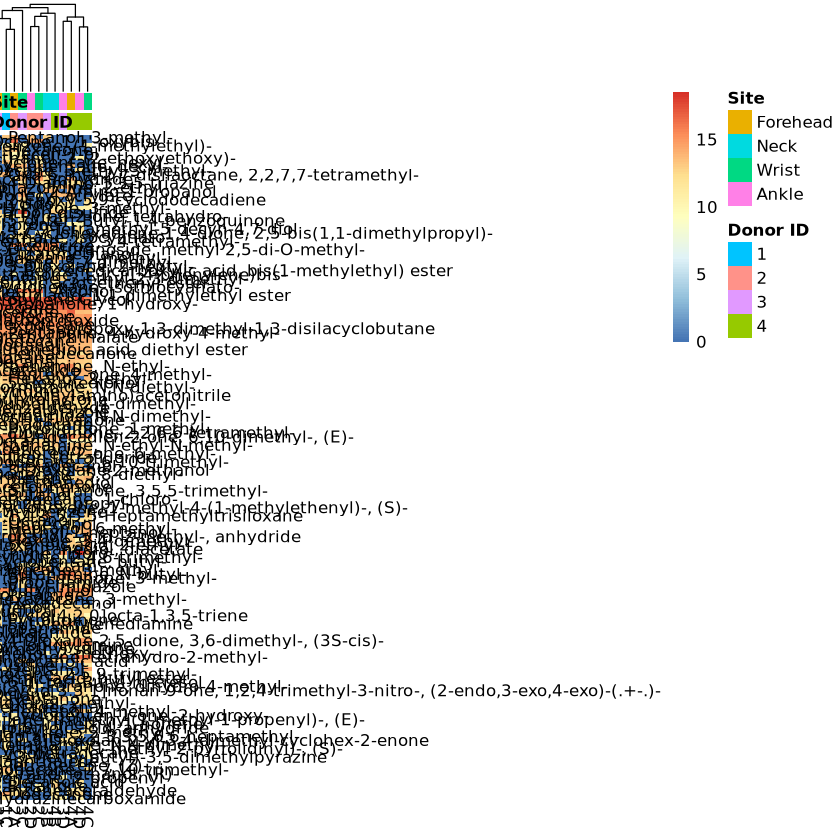

In [24]:
p = pheatmap::pheatmap(mat,  annotation_col = anno_col)$gtable
ggsave('./results/heatmap_primary.pdf', p, height = 24, width = 10, unit = "in", dpi = 400)

In [25]:
D_bc <- vegan::vegdist(t(mat), method="bray", na.rm = FALSE)

In [26]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 100)

pco = cmdscale(D_bc, k = 2, eig = TRUE)
meta$sample_id

[1] "2A" "3A" "4A" "2B" "3B" "4B" "1C" "2C" "3C" "4C" "2D" "3D" "4D"

In [27]:
df = data.frame(
  Sample = meta$sample_id,
  PCoA1 = pco$points[,1],
  PCoA2 = pco$points[,2],
  donor = meta$donor_id,
  site  = meta$location
)

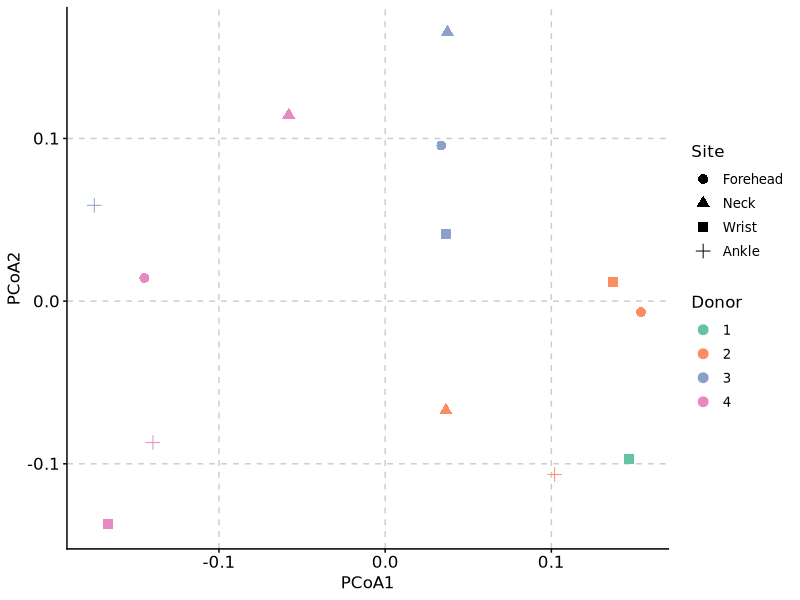

In [28]:
p = ggplot(df, aes(PCoA1, PCoA2, color = donor, shape = site)) +
  geom_point(size = 3) +
  theme_function() + 
  scale_color_discrete(name = "Donor", palette = "Set2") +
  scale_shape_discrete(name = "Site")

print(p)
ggsave('./results/pcoa_primary.pdf', p, height = 4, width = 6, unit = "in", dpi = 400)

In [29]:
# RQ: donor variability
# if donor variablility can be detected, the variation should be larger than site variability.
# use beta diversity
# Bray–Curtis distance
D <- vegan::vegdist(t(mat), method = "bray")   # if X already log-transformed, use vegdist(X, ...)

dmat <- as.matrix(D)

don <- meta$donor_id

# 2) Extract upper triangle distances
within  <- dmat[outer(don, don, "==") & upper.tri(dmat)]
between <- dmat[outer(don, don, "!=") & upper.tri(dmat)]

# 3) Summaries + effect size
within_mean    = mean(within,  na.rm = TRUE)
between_mean   = mean(between, na.rm = TRUE)
diff = mean(between, na.rm = TRUE) - mean(within, na.rm = TRUE)

print(within_mean)
print(between_mean)
print(diff)

[1] 0.3080014
[1] 0.3468774
[1] 0.03887601


In [32]:
don

[1] "2" "3" "4" "2" "3" "4" "1" "2" "3" "4" "2" "3" "4"

In [33]:
# permutation test
set.seed(1)

B <- 10000
perm <- replicate(B, {
  don_p <- sample(don)
  w <- dmat[outer(don_p, don_p, "==") & upper.tri(dmat)]
  b <- dmat[outer(don_p, don_p, "!=") & upper.tri(dmat)]
  mean(b, na.rm=TRUE) - mean(w, na.rm=TRUE)
})
pval <- mean(perm >= diff)
print(pval)

[1] 0.0042


In [34]:
# which location is credible
# use the all data (before removing samples)
data_ = read_csv("./results/pdms_feature_filtered_normalized.csv")
data_ = data_ %>% 
    pivot_longer(!c(Name, CAS), names_to = "sample_loc", values_to = "peak") %>% 
    mutate(donor_id = str_extract(sample_loc, "\\d")) %>% 
    mutate(location = str_extract(sample_loc, "[A-D]")) %>% 
    mutate(location = factor(location, 
                            levels = c('A', "B", "C", "D"), 
                            labels = c("Forehead", "Neck","Wrist", "Ankle"))) 

Rows: 160 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Name, CAS
dbl (14): 2A, 3A, 4A, 2B, 3B, 4B, 1C, 2C, 3C, 4C, 1D, 2D, 3D, 4D

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


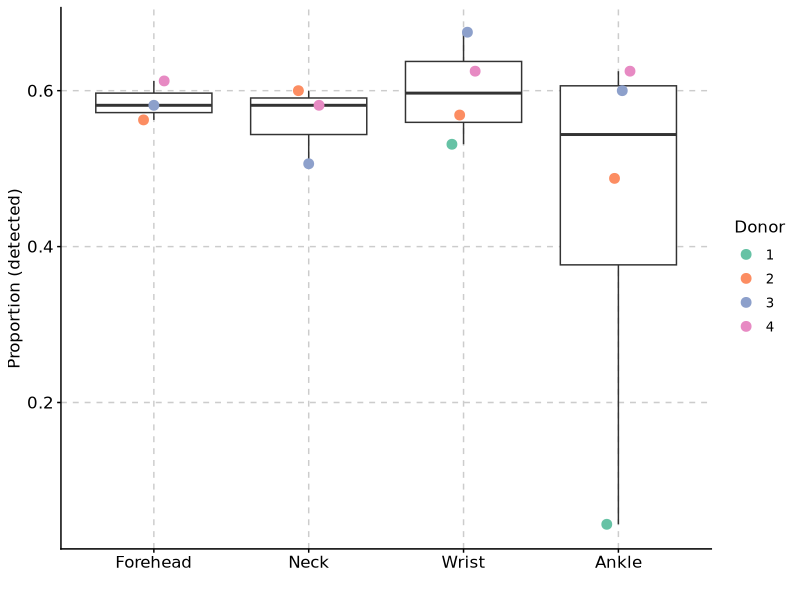

In [35]:
n_features = data_ %>% distinct(Name) %>% pull(Name) %>% length(.)
data__ = data_ %>% 
    mutate(detected = ifelse(is.na(peak), 0, 1)) %>%
    group_by(sample_loc) %>% 
    mutate(n_detected = sum(detected)) %>% 
    ungroup() %>% 
    filter(!duplicated(sample_loc)) %>% 
    mutate(total = n_features) %>% 
    mutate(detected_prop = n_detected/total) 
p = data__ %>% 
    ggplot(aes(location, detected_prop)) + 
        geom_boxplot() + 
        geom_point(aes(color = donor_id), size= 3, position = position_dodge(width = 0.2)) + 
        theme_function() +
        scale_color_discrete(name = "Donor", palette = "Set2")+
        xlab("") + 
        ylab("Proportion (detected)")

print(p)
ggsave('./results/location_box.pdf', p, height = 4, width = 6, unit = "in", dpi = 400)

In [36]:
data__ %>% write_csv("./results/detected_prop.csv")

In [37]:
data__ = read_csv("./results/detected_prop.csv")

Rows: 14 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): Name, CAS, sample_loc, location
dbl (6): peak, donor_id, detected, n_detected, total, detected_prop

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
data__ %>% 
    group_by(location) %>% 
    summarise(
        mean = mean(detected_prop),
        sd = sd(detected_prop),
        cv = sd/mean)

location,mean,sd,cv
<chr>,<dbl>,<dbl>,<dbl>
Ankle,0.4390625,0.27024174,0.61549721
Forehead,0.5854167,0.02525907,0.04314717
Neck,0.5625000,0.04960784,0.08819171
Wrist,0.6000000,0.06312191,0.10520318


In [39]:
# diagnosis of compounds comparing room, cloth, S3, empty GC-MS

In [40]:
# forehead and ankle were not reliable, only using neck and wrist
data = read_csv("./results/pdms_feature_filtered_normalized.csv")
keep_cols = c(
    'Name', 'CAS', '2B','3B','4B','1C','2C','3C','4C')
data = data %>% dplyr::select(all_of(keep_cols)) 

# some CASs were incorrect
modify = tibble(
Name = c("2-(Diethylamino)acetonitrile", "Pentadecanal-","4-Vinyl-imidazole", "Ethyne, fluoro-"),
CAS = c("3010-02-4", "2765-11-9", "664107","2713-09-9")
)

for(i in 1:nrow(modify)){
    data[data$Name == modify$Name[i], "CAS"] = modify$CAS[i]
}    
skin_cas = data %>% pull(CAS)

Rows: 160 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Name, CAS
dbl (14): 2A, 3A, 4A, 2B, 3B, 4B, 1C, 2C, 3C, 4C, 1D, 2D, 3D, 4D

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [41]:
# clothing PDMS

In [42]:
sheets = readxl::excel_sheets('./data/pdms_data/Emory Skin Sample Data.xlsx')
bools = sapply(sheets, function(x) str_detect(x, "E"))
pattern_id = sheets[bools]

In [43]:
datas= list()
for (i in pattern_id){
    out = tryCatch(
        expr = {
            readxl::read_excel('./data/pdms_data/Emory Skin Sample Data.xlsx', sheet = i) %>% 
                group_by(CAS) %>% 
                mutate(Area_sum = sum(Area)) %>%
                filter(!duplicated(CAS)) %>% 
                select(Name, CAS, !!i := Area_sum) %>% 
                # remove siloxane and trimethylsilylated peaks 
                filter(!Name %in% removed) 
        }, error = function(e){
            NULL
        }
        )
    datas[[i]] = out    
}


In [44]:
# combine
combined = reduce(datas, full_join, by = c("Name", "CAS")) 

In [45]:
combined %>% filter(!str_detect(CAS, "-")) %>% pull(Name)

modify = tibble(
Name = c(
'1,2-Propanediol, 2-acetate', 
'Cyclohexane, 1-ethenyl-1-methyl-2-(1-methylethenyl)-4-(1-methylethylidene)-',
'2-(Diethylamino)acetonitrile',
'1,3,5-Cycloheptatriene, 7,7-dimethyl-'),
CAS = c("6214-01-3", 
        "3242-08-8",
        "3010-02-4",
        "4082-89-7")
)

for(i in 1:nrow(modify)){
    combined[combined$Name == modify$Name[i], "CAS"] = modify$CAS[i]
}    

[1] "1,2-Propanediol, 2-acetate"                                                 
[2] "Cyclohexane, 1-ethenyl-1-methyl-2-(1-methylethenyl)-4-(1-methylethylidene)-"
[3] "2-(Diethylamino)acetonitrile"                                               
[4] "1,3,5-Cycloheptatriene, 7,7-dimethyl-"

In [46]:
combined %>% filter(!str_detect(CAS, "-")) %>% pull(Name)

character(0)

In [47]:
# cloth PDMS, under same conditions, cloth compounds should be consistent across samples, removing some contamination during handling
cloth_cas = combined %>% 
    mutate(credible = !is.na(`1E`) | !is.na(`2E`)) %>% 
    filter(credible) %>% 
    pull(CAS)
print(length(cloth_cas))

[1] 257


In [48]:
# room control
sheets = readxl::excel_sheets('./data/pdms_data/Emory Skin Sample Data.xlsx')
bools = sapply(sheets, function(x) str_detect(x, "5"))
pattern_id = sheets[bools]
pattern_id               

[1] "5A" "5B"

In [49]:
datas= list()
for (i in pattern_id){
    out = tryCatch(
        expr = {
            readxl::read_excel('./data/pdms_data/Emory Skin Sample Data.xlsx', sheet = i) %>% 
                group_by(CAS) %>% 
                mutate(Area_sum = sum(Area)) %>%
                filter(!duplicated(CAS)) %>% 
                select(Name, CAS, !!i := Area_sum) %>% 
                # remove siloxane and trimethylsilylated peaks 
                filter(!Name %in% removed) 
        }, error = function(e){
            NULL
        }
        )
    datas[[i]] = out    
}


In [50]:
# combine
combined = reduce(datas, full_join, by = c("Name", "CAS")) 
combined %>% filter(!str_detect(CAS, "-")) %>% pull(Name)

[1] "Methanesulfonic anhydride"            
[2] "1,2-Propanediol, 2-acetate"           
[3] "2-(Diethylamino)acetonitrile"         
[4] "1,3,5-Cycloheptatriene, 7,7-dimethyl-"
[5] "Ethyne, fluoro-"

In [51]:
modify = tibble(
Name = c(
'Methanesulfonic anhydride',
'1,2-Propanediol, 2-acetate',
'2-(Diethylamino)acetonitrile',
'1,3,5-Cycloheptatriene, 7,7-dimethyl-',
'Ethyne, fluoro-'),

CAS = c("7143-01-3", 
        "6214-01-3",
        "3010-02-4",
        "7557-11-1",
        "2713-09-9")
)

for(i in 1:nrow(modify)){
    combined[combined$Name == modify$Name[i], "CAS"] = modify$CAS[i]
}  

In [52]:
combined %>% filter(!str_detect(CAS, "-")) %>% pull(Name)

character(0)

In [53]:
# env, under same conditions, env compounds should be consistent across samples, removing some contamination during handling
room_cas = combined %>% 
    mutate(credible = !is.na(`5A`) | !is.na(`5B`)) %>% 
    filter(credible) %>% 
    pull(CAS)
print(length(room_cas))

[1] 210


In [54]:
# GC MS control
pattern_id = c("GCMS_only")

In [55]:
datas= list()
for (i in pattern_id){
    out = tryCatch(
        expr = {
            readxl::read_excel('./data/pdms_data/Emory Skin Sample Data.xlsx', sheet = i) %>% 
                group_by(CAS) %>% 
                mutate(Area_sum = sum(Area)) %>%
                filter(!duplicated(CAS)) %>% 
                select(Name, CAS, !!i := Area_sum)   %>% 
                # remove siloxane and trimethylsilylated peaks 
                filter(!Name %in% removed)  
        }, error = function(e){
            NULL
        }
        )
    datas[[i]] = out    
}

In [56]:
# combine
combined = reduce(datas, full_join, by = c("Name", "CAS")) 

In [57]:
combined %>% filter(!str_detect(CAS, "-")) %>% pull(Name)

character(0)

In [58]:
# env, under same conditions, env compounds should be consistent across samples, removing some contamination during handling
gcms_only_cas = combined %>% 
    mutate(credible = !is.na(`GCMS_only`)) %>% 
    filter(credible) %>% 
    pull(CAS)
print(length(gcms_only_cas))

[1] 56


In [59]:
# collect all compound and CAS ID
sheets = readxl::excel_sheets('./data/pdms_data/Emory Skin Sample Data.xlsx')
datas= list()
for (i in sheets){
    out = tryCatch(
        expr = {
            readxl::read_excel('./data/pdms_data/Emory Skin Sample Data.xlsx', sheet = i) %>% 
                group_by(CAS) %>% 
                mutate(Area_sum = sum(Area)) %>%
                filter(!duplicated(CAS)) %>% 
                select(Name, CAS, !!i := Area_sum) %>% 
                # remove siloxane and trimethylsilylated peaks 
                filter(!Name %in% removed)   
                
        }, error = function(e){
            NULL
        }
        )
    datas[[i]] = out    
}

In [60]:
cas_dict = reduce(datas, full_join, by = c("Name", "CAS")) %>% 
    select(Name, CAS)

In [61]:
cas_dict %>% nrow()

[1] 1221

In [62]:
# sys review compounds -> cirpy to get CAS, but not complete
s3 = readxl::read_excel("./results/summary_cas.xlsx")
nrow(s3)

New names:
• `` -> `...1`


[1] 128

In [64]:
s3 %>% dplyr::rename(name = Name) %>%
    mutate(name = str_to_lower(name)) %>% 
    left_join(cas_dict %>% mutate(name = str_to_lower(Name)), by = "name") %>% 
    writexl::write_xlsx("./results/summary_cas_added.xlsx")

In [65]:
s3_modified = readxl::read_excel("./results/summary_cas_added_modified.xlsx")
s3_modified %>% nrow()

[1] 128

In [66]:
# make sure to remove siloxane and trimethylsilylated peaks 
s3_modified = s3_modified %>% filter(!name %in% str_to_lower(removed))

In [67]:
s3_modified %>% nrow()

[1] 128

In [68]:
# keep only CAS available
s3_modified = s3_modified %>% filter(!is.na(CAS_new))
s3_cas = s3_modified %>% pull(CAS_new)
s3_modified %>% nrow()
length(s3_cas)

[1] 115

[1] 115

In [69]:
# update cas_dict
s3_cas_dict = s3_modified %>% mutate(Name = str_to_title(name)) %>% 
    select(Name, CAS = CAS_new)

In [70]:
cas_dict_new = bind_rows(cas_dict, s3_cas_dict) %>% 
    filter(!duplicated(CAS))

In [71]:
cas_dict_new %>% write_csv("./results/cas_dict.csv")

In [72]:
# some of CASs were incorrect. revise
modify1 = tibble(
Name = c("2-(Diethylamino)acetonitrile", "Pentadecanal-","4-Vinyl-imidazole", "Ethyne, fluoro-"),
CAS = c("3010-02-4", "2765-11-9", "664107","2713-09-9")
)

modify2 = tibble(
Name = c(
'1,2-Propanediol, 2-acetate', 
'Cyclohexane, 1-ethenyl-1-methyl-2-(1-methylethenyl)-4-(1-methylethylidene)-',
'2-(Diethylamino)acetonitrile',
'1,3,5-Cycloheptatriene, 7,7-dimethyl-'),
CAS = c("6214-01-3", 
        "3242-08-8",
        "3010-02-4",
        "4082-89-7")
)

modify3 = tibble(
Name = c(
'Methanesulfonic anhydride',
'1,2-Propanediol, 2-acetate',
'2-(Diethylamino)acetonitrile',
'1,3,5-Cycloheptatriene, 7,7-dimethyl-',
'Ethyne, fluoro-'),

CAS = c("7143-01-3", 
        "6214-01-3",
        "3010-02-4",
        "7557-11-1",
        "2713-09-9")
)

modify = bind_rows(modify1, modify2, modify3) %>% 
    filter(!duplicated(CAS))

In [73]:
cas_dict = read_csv("./results/cas_dict.csv")

Rows: 1267 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Name, CAS

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [74]:
# revise
for(i in 1:nrow(modify)){
    cas_dict[cas_dict$Name == modify$Name[i], "CAS"] = modify$CAS[i]
}  

In [75]:
cas_dict %>% write_csv("./results/cas_dict_revised.csv")

In [76]:
# now compare, detected skin, clothing, room, GCMS_only, Mitra

In [77]:
# credible all compounts
all_cas = unique(c(skin_cas, cloth_cas, room_cas, gcms_only_cas, s3_cas))
length(all_cas)

[1] 517

In [78]:
cas_dict_revised = read_csv("./results/cas_dict_revised.csv")

Rows: 1267 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Name, CAS

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [79]:
detected_matrix = tibble(CAS = all_cas) %>% 
    mutate(skin =  ifelse(CAS %in% skin_cas, 1, 0)) %>% 
    mutate(cloth = ifelse(CAS %in% cloth_cas, 1, 0)) %>% 
    mutate(room = ifelse(CAS %in% room_cas, 1, 0)) %>% 
    mutate(gcms_only = ifelse(CAS %in% gcms_only_cas, 1, 0)) %>% 
    mutate(s3 = ifelse(CAS %in% s3_cas, 1, 0)) %>% 
    left_join(cas_dict_revised, by = "CAS") 

In [80]:
detected_matrix %>% write_csv("./results/detected_matrix.csv")

In [81]:
# Venn
detected_matrix = read_csv("./results/detected_matrix.csv")

Rows: 517 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): CAS, Name
dbl (5): skin, cloth, room, gcms_only, s3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [82]:
skin = detected_matrix %>% filter(skin == 1) %>% pull(CAS)
length(skin)

cloth = detected_matrix %>% filter(cloth == 1) %>% pull(CAS)
length(cloth)

room = detected_matrix %>% filter(room == 1) %>% pull(CAS)
length(room)

gcms_only = detected_matrix %>% filter(gcms_only == 1) %>% pull(CAS)
length(gcms_only)

s3 = detected_matrix %>% filter(s3 == 1) %>% pull(CAS)
length(s3)

[1] 160

[1] 256

[1] 209

[1] 56

[1] 108

In [120]:
# up set plot
# row -> VOC
# columns - > catgory (binary)
data = detected_matrix %>% 
    dplyr::select(Name, 
                  skin, 
                  cloth, 
                  room, 
                  gcms_only, 
                  s3) %>% 
    dplyr::rename(Skin = skin, 
                  "Clothing-control" = cloth,
                 "Room-control" = room,
                 "Blank-control" = gcms_only, "Mitra et al." = s3) %>% 
    as.data.frame()

In [144]:
library(ggplotify)
library(ComplexUpset)


Attaching package: ‘ComplexUpset’


The following object is masked from ‘package:UpSetR’:

    upset




Warning message:
“Duplicated aesthetics after name standardisation: width”


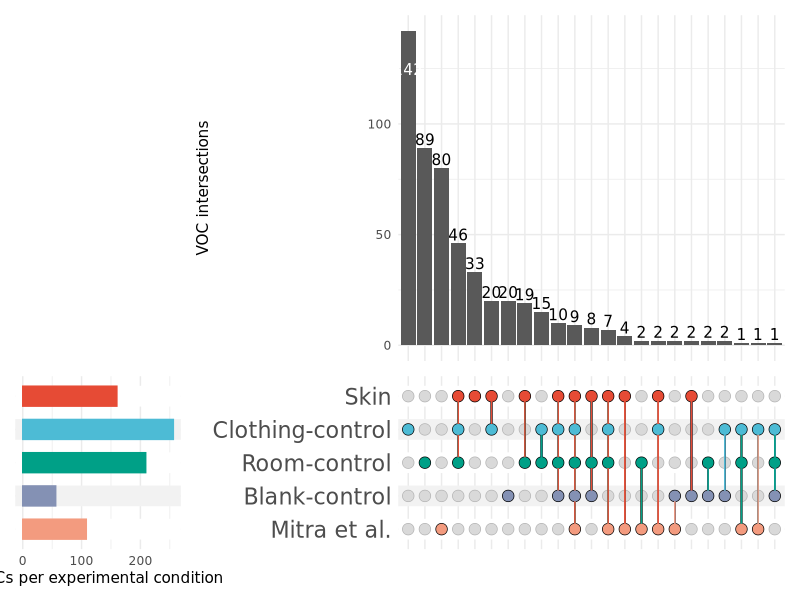

In [182]:
p = ComplexUpset::upset(
  data,
  intersect = rev(c(
    "Skin",
    "Clothing-control",
    "Room-control",
    "Blank-control",
    "Mitra et al."
  )),
  sort_sets = FALSE,
  sort_intersections = "descending",
   base_annotations = list(
    "VOC Intersections" =
      ComplexUpset::intersection_size() +
      scale_y_continuous(name = "VOC intersections")),
  set_sizes =
    ComplexUpset::upset_set_size() +
    scale_y_continuous(name = "VOCs per experimental condition"),
  queries = list(
    ComplexUpset::upset_query(set = "Skin",color = "#E64B35", fill = "#E64B35"),
    ComplexUpset::upset_query(set = "Clothing-control",color = "#4DBBD5", fill = "#4DBBD5"),
    ComplexUpset::upset_query(set = "Room-control", color = "#00A087", fill = "#00A087"),
    ComplexUpset::upset_query(set = "Blank-control", color ="#8491B4", fill = "#8491B4"),
    ComplexUpset::upset_query(set = "Mitra et al.", color = "#F39B7F", fill = "#F39B7F")),
  themes = ComplexUpset::upset_modify_themes(
    list(
      "intersections_matrix" = theme(
        axis.title.x = element_blank()
      ))))
p = p + theme(text = element_text(size = 20))


ggsave("./results/upset.pdf", plot = as.ggplot(p), height = 5, width = 10, unit = "in", dpi = 400)
p

In [83]:
v= venn.diagram(
  x = list(skin, 
           cloth, 
           room, 
           gcms_only, 
           s3),
  category.names = c("Skin",  "Cloth-control" , "Room-control" , "Blank-control", "Mitra et al."),
  filename = NULL,
  output=FALSE,
    margin = 0.18,
  cat.cex = 0.8,
  cex = 0.8,
  #cat.dist = 0.07   # try 0.03–0.12
)

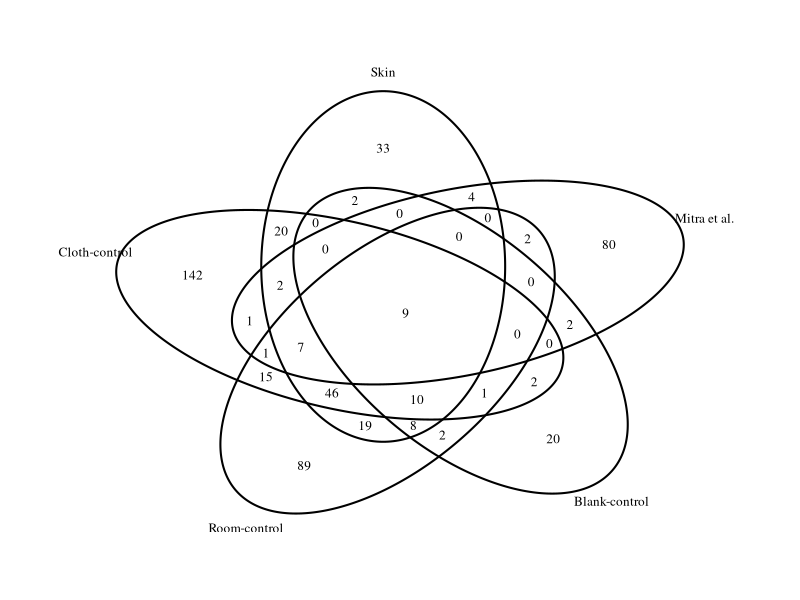

In [84]:
v

In [460]:
pdf("./results/venn_diagram.pdf", width = 5, height = 5)
grid.newpage(); grid.draw(v)
dev.off()

agg_record_978173948 
                   2

In [429]:
library(gplots)

In [430]:
x = list("Skin" = skin, 
         "Cloth" = cloth, 
         "Room" = room, 
         "Blank" =   gcms_only, 
         "Mitra et al" =   s3)

ItemsList <- venn(x, show.plot = FALSE)

lengths(attributes(ItemsList)$intersections)
list_res = attributes(ItemsList)$intersections

Cloth:Room                        Room:Blank 
                               15                                 2 
                       Skin:Blank                        Skin:Cloth 
                                2                                20 
                      Cloth:Blank                       Mitra et al 
                                2                                80 
                  Skin:Cloth:Room                   Skin:Room:Blank 
                               46                                 8 
                 Cloth:Room:Blank                  Room:Mitra et al 
                                1                                 2 
                 Skin:Mitra et al                 Blank:Mitra et al 
                                4                                 2 
                Cloth:Mitra et al             Skin:Cloth:Room:Blank 
                                1                                10 
           Cloth:Room:Mitra et al            Skin:Cloth:Mitra et al 
                                1                                 2 
      Skin:Cloth:Room:Mitra et al Skin:Cloth:Room:Blank:Mitra et al 
                                7                                 9 
                             Room                              Skin 
                               89                                33 
                            Blank                             Cloth 
                               20                               142 
                        Skin:Room 
                               19

In [431]:
# inspect which
cas_dict = read_csv("./results/cas_dict_revised.csv")

Rows: 1267 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Name, CAS

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [432]:
list_res_renamed = list()
for(i in 1:length(list_res)){
    key = names(list_res)[i]
    values = list_res[[i]]
   
    values_re = cas_dict %>% filter(CAS %in% values) %>% pull(Name) %>% paste(collapse =", ")
    list_res_renamed[[key]] = values_re
}

In [433]:
ns = lapply(list_res, function(x) length(x)) %>% unlist()

In [434]:
tibble("Intersect" =  names(list_res),
      "N" = ns, 
      "VOC" = unlist(list_res_renamed)) %>% 
    writexl::write_xlsx('./results/table_intersect.xlsx')

In [435]:
overlaps = readxl::read_excel('./results/table_intersect.xlsx')

In [436]:
S = skin
C = cloth # Clothing PDMS
R = room # Room PDMS
E = gcms_only # Empty GCMS
M = s3 # Mit et al

In [438]:
# In skin
length(S)

[1] 160

In [439]:
# In skin, how many were clothing?
length(intersect(S, C))

[1] 94

In [440]:
# In skin, how many were room control
length(intersect(S, R))

[1] 99

In [441]:
# In skin, how many were blank control
length(intersect(S, E))

[1] 29

In [443]:
# VOC overlapping across skin, cloth, room and blank
check = intersect(intersect(S, C),  intersect(R, E))
length(check)

[1] 19

In [ ]:
cas_dict %>% filter(CAS %in% check)

In [ ]:
# Only S
onlyS = setdiff(S, union(union(union(E, R), C), M))
print(length(onlyS))
cas_dict %>% filter(CAS %in% onlyS) %>% pull(Name)

In [450]:
length(M)

[1] 108

In [ ]:
onlyM = setdiff(M, union(union(S, C), union(R, E)))
print(length(onlyM))
cas_dict %>% filter(CAS %in% onlyM) %>% pull(Name)

In [ ]:
# get the chemical hierarchical name
# use py cirpy
onlyM %>% sprintf('"%s"', .) %>% paste(., collapse = ", ") %>% noquote()

In [235]:
# only S
keys <- c(
 'NA',
 'HAMGRBXTJNITHG-UHFFFAOYSA-N',
 'NA',
 'SKBBQSLSGRSQAJ-UHFFFAOYSA-N',
 'HNZUNIKWNYHEJJ-FMIVXFBMSA-N',
 'FHVAUDREWWXPRW-UHFFFAOYSA-N',
 'NKJOXAZJBOMXID-UHFFFAOYSA-N',
 'WWPCLIMUTNKTDY-UHFFFAOYSA-N',
 'BXWNKGSJHAJOGX-UHFFFAOYSA-N',
 'QGJOPFRUJISHPQ-UHFFFAOYSA-N',
 'AJPGNQYBSTXCJE-UHFFFAOYSA-N',
 'NA',
 'MTZWHHIREPJPTG-UHFFFAOYSA-N',
 'WMOVHXAZOJBABW-UHFFFAOYSA-N',
 'SZLVYXIKAAFTFY-UHFFFAOYSA-N',
 'NA',
 'XGQJZNCFDLXSIJ-UHFFFAOYSA-N',
 'MMASVVOQIKCFJZ-UHFFFAOYSA-N',
 'DHXFOYLEDAOQRR-UHFFFAOYSA-N',
 'ZZYASVWWDLJXIM-UHFFFAOYSA-N',
 'JCJGCZBSINPZAJ-UHFFFAOYSA-N',
 'WYVAMUWZEOHJOQ-UHFFFAOYSA-N',
 'ALZLTHLQMAFAPA-UHFFFAOYSA-N',
 'TVCXVUHHCUYLGX-UHFFFAOYSA-N',
 'QLNJFJADRCOGBJ-UHFFFAOYSA-N',
 'LEVWYRKDKASIDU-IMJSIDKUSA-N',
 'JQVDAXLFBXTEQA-UHFFFAOYSA-N',
 'BKMMTJMQCTUHRP-UHFFFAOYSA-N',
 'KNCYXPMJDCCGSJ-UHFFFAOYSA-N',
 'NA',
 'NA',
 'NA',
 'LWJBQKKNODYJEI-UHFFFAOYSA-N',
 'ZAGHKONXGGSVDV-UHFFFAOYSA-N',
 'NA',
 'NMJJFJNHVMGPGM-UHFFFAOYSA-N'
)
 

In [246]:
# only M
keys = c(
'MNWFXJYAOYHMED-UHFFFAOYSA-N',
 'VOLMSPGWNYJHQQ-UHFFFAOYSA-N',
 'YLYBTZIQSIBWLI-UHFFFAOYSA-N',
 'XBDQKXXYIPTUBI-UHFFFAOYSA-N',
 'WQEPLUUGTLDZJY-UHFFFAOYSA-N',
 'XMVBHZBLHNOQON-UHFFFAOYSA-N',
 'OSWPMRLSEDHDFF-UHFFFAOYSA-N',
 'YPNZJHFXFVLXSE-UHFFFAOYSA-N',
 'KSKXSFZGARKWOW-GQCTYLIASA-N',
 'NA',
 'LFQSCWFLJHTTHZ-WFVSFCRTSA-N',
 'XCXKZBWAKKPFCJ-UHFFFAOYSA-N',
 'HQYSAIKKBLWFBW-UHFFFAOYSA-N',
 'WWZKQHOCKIZLMA-UHFFFAOYSA-N',
 'KMTDMTZBNYGUNX-UHFFFAOYSA-N',
 'NA',
 'FBUKVWPVBMHYJY-UHFFFAOYSA-N',
 'VYUNLDVEMSMJNP-UHFFFAOYSA-N',
 'JFDZBHWFFUWGJE-UHFFFAOYSA-N',
 'KYWIYKKSMDLRDC-UHFFFAOYSA-N',
 'NA',
 'QIQXTHQIDYTFRH-UHFFFAOYSA-N',
 'FNWWOHKUXFTKGN-UHFFFAOYSA-N',
 'BZKFMUIJRXWWQK-UHFFFAOYSA-N',
 'GRWFGVWFFZKLTI-UHFFFAOYSA-N',
 'FXHGMKSSBGDXIY-UHFFFAOYSA-N',
 'GWLLTEXUIOFAFE-UHFFFAOYSA-N',
 'RHDGNLCLDBVESU-UHFFFAOYSA-N',
 'PANBRUWVURLWGY-MDZDMXLPSA-N',
 'HNZUNIKWNYHEJJ-FMIVXFBMSA-N',
 'WPYMKLBDIGXBTP-UHFFFAOYSA-N',
 'FUZZWVXGSFPDMH-UHFFFAOYSA-N',
 'OLGGLCIDAMICTA-UHFFFAOYSA-N',
 'BQOFWKZOCNGFEC-UHFFFAOYSA-N',
 'CVQUWLDCFXOXEN-UHFFFAOYSA-N',
 'UYSGWTCETIRUHO-UHFFFAOYSA-N',
 'FPZWZCWUIYYYBU-UHFFFAOYSA-N',
 'RTYRONIMTRDBLT-ONEGZZNKSA-N',
 'ZSIAUFGUXNUGDI-UHFFFAOYSA-N',
 'YNPNZTXNASCQKK-UHFFFAOYSA-N',
 'OYHQOLUKZRVURQ-HZJYTTRNSA-N',
 'SFNALCNOMXIBKG-UHFFFAOYSA-N',
 'CDOSHBSSFJOMGT-UHFFFAOYSA-N',
 'BTFJIXJJCSYFAL-UHFFFAOYSA-N',
 'GFAZHVHNLUBROE-UHFFFAOYSA-N',
 'ANISOHQJBAQUQP-UHFFFAOYSA-N',
 'RWCCWEUUXYIKHB-UHFFFAOYSA-N',
 'YWHLKYXPLRWGSE-UHFFFAOYSA-N',
 'WHCKFZOMBDMRLO-UHFFFAOYSA-N',
 'LVBXEMGDVWVTGY-VOTSOKGWSA-N',
 'POULHZVOKOAJMA-UHFFFAOYSA-N',
 'OYHQOLUKZRVURQ-HZJYTTRNSA-N',
 'BSAIUMLZVGUGKX-FPLPWBNLSA-N',
 'MCFZBCCYOPSZLG-UHFFFAOYSA-N',
 'NA',
 'MLUCVPSAIODCQM-IHWYPQMZSA-N',
 'XMGQYMWWDOXHJM-JTQLQIEISA-N',
 'CYIFVRUOHKNECG-UHFFFAOYSA-N',
 'IPCSVZSSVZVIGE-UHFFFAOYSA-N',
 'IFYYFLINQYPWGJ-UHFFFAOYSA-N',
 'GWYFCOCPABKNJV-UHFFFAOYSA-N',
 'XSNQECSCDATQEL-UHFFFAOYSA-N',
 'CJPNOLIZCWDHJK-UHFFFAOYSA-N',
 'XEKOWRVHYACXOJ-UHFFFAOYSA-N',
 'TZMFJUDUGYTVRY-UHFFFAOYSA-N',
 'TUNFSRHWOTWDNC-UHFFFAOYSA-N',
 'MMFCJPPRCYDLLZ-CMDGGOBGSA-N',
 'BDCFWIDZNLCTMF-UHFFFAOYSA-N',
 'LFQSCWFLJHTTHZ-UHFFFAOYSA-N',
 'VKCYHJWLYTUGCC-UHFFFAOYSA-N',
 'PHXATPHONSXBIL-JTQLQIEISA-N',
 'JXZJRYDTSDCGLO-UHFFFAOYSA-N',
 'ZAJNGDIORYACQU-UHFFFAOYSA-N',
 'GWSURTDMLUFMJH-FOCLMDBBSA-N',
 'FERIUCNNQQJTOY-UHFFFAOYSA-N',
 'KEMQGTRYUADPNZ-UHFFFAOYSA-N',
 'XOJVVFBFDXDTEG-UHFFFAOYSA-N',
 'IVSZLXZYQVIEFR-UHFFFAOYSA-N',
 'BGTOWKSIORTVQH-UHFFFAOYSA-N',
 'NA')

In [ ]:
classification_list <- map(keys, get_classification)

In [248]:
cas_inchikey = tibble(CAS = onlyM, inchikey = keys)

In [249]:
outs = list()
for (i in 1:length(classification_list)){

    tryCatch(
    expr = {
        x = classification_list[[i]]
        key = str_replace(x@meta$inchikey, "InChIKey=", "")
        classes = x@classification
        out_ = classes %>% 
            select(Level, !!key :=Classification)
        outs[[key]] = out_
    }, error = function(e){
        NULL
    }
    )
}

In [ ]:
summary_ = reduce(outs, full_join, by = c("Level")) %>% 
    pivot_longer(!Level, names_to = "inchikey", values_to = "class") %>% 
    left_join(cas_inchikey, by = "inchikey") %>% 
    left_join(cas_dict, by = "CAS") 

In [251]:
# summary_ %>% write_csv("./results/summary_onlyS.csv")
summary_ %>% write_csv("./results/summary_onlyM.csv")

In [ ]:
summary = read_csv("./results/summary_onlyS.csv")

In [ ]:
summary = read_csv("./results/summary_onlyM.csv")

In [ ]:
summary %>% filter(str_detect(class, "keton"))

In [ ]:
summary %>% filter(str_detect(Name, "Nonanone"))